In [1]:
import pandas as pd
import tensorflow as tf
import os
from working_data import clean_cols, clean_non_minute_rows, alt_label_df as label_df, normalize_by_window, split_df, add_bollinger_bands
from data_builder_trans import create_dataset_generator, get_total_rows
from model_builder_trans import build_transformer_model, combined_loss
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

2024-10-24 15:11:10.220407: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-24 15:11:10.825753: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-24 15:11:12.406169: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-10-24 15:11:14.998524: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-24 15:11:15.204000: 

In [2]:
NORMALIZING_WINDOW_SIZE = 60*24
LABELING_WINDOW_SIZE = 20
POSITIVE_SLOPE = 0.3
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 8
BATCH_SIZE = 32
NUM_TRANSFORMER_TOKENS = 64
D_MODEL = 32
FF_DIM = D_MODEL*2
NUM_HEADS = D_MODEL//8
NUM_TRANSFORMER_LAYERS = 2

In [3]:
source_csv = "data/GBPUSD/minutes.csv"
working_path = "working"

In [4]:
df = pd.read_csv(source_csv)
df = clean_non_minute_rows(df)
df = clean_cols(df)
break_point = len(df) - len(df)//20
df = df[break_point:]
df = normalize_by_window(
    df, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close'
    ])
print("labeling")
df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
print(df['target'].value_counts())
split_df(df=df, dump_path=working_path)

labeling
target
0    425855
1     21819
Name: count, dtype: int64


In [5]:
input_shape = (NUM_TRANSFORMER_TOKENS, 4)  #4 features per token
model = build_transformer_model(input_shape, d_model=D_MODEL, ff_dim=FF_DIM, num_heads=NUM_HEADS, num_layers=NUM_TRANSFORMER_LAYERS, training=True)
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()
model.compile(optimizer='adam', 
              loss=combined_loss, 
              metrics=['accuracy',auc, prec])



(None, 64, 4)


(None, 64, 32)


In [6]:
train_file = os.path.join(working_path, 'train.csv')
val_file = os.path.join(working_path, 'val.csv')
test_file = os.path.join(working_path, 'test.csv')

train_dataset= create_dataset_generator(train_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS, smote=True, shuffle=True, repeat=True).prefetch(tf.data.AUTOTUNE)
val_dataset = create_dataset_generator(val_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS, repeat=True).prefetch(tf.data.AUTOTUNE)
test_dataset = create_dataset_generator(test_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS).prefetch(tf.data.AUTOTUNE)

train_steps_per_epoch = get_total_rows(train_file, smote=True, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE
val_steps_per_epoch = get_total_rows(val_file, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE
test_steps_per_epoch = get_total_rows(test_file, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE


In [7]:
for data in train_dataset.take(1):
    inputs, labels = data
    print("Inputs:", inputs.numpy())
    print("Labels:", labels.numpy())

Inputs: [[[0.0306644  0.06132879 0.02385009 0.0306644 ]
  [0.0306644  0.03577513 0.         0.00340715]
  [0.01213172 0.05199307 0.         0.04506066]
  ...
  [0.43970317 0.45269015 0.41558442 0.4174397 ]
  [0.4174397  0.432282   0.38404453 0.42486086]
  [0.42300555 0.45825604 0.42300555 0.45269015]]

 [[0.5199758  0.52179176 0.51452786 0.51634383]
  [0.5157385  0.5205811  0.51452786 0.5205811 ]
  [0.5205811  0.52300245 0.5205811  0.5205811 ]
  ...
  [0.46004844 0.4642857  0.46004844 0.46065375]
  [0.46125907 0.46670702 0.46065375 0.46670702]
  [0.46670702 0.46912834 0.46670702 0.46670702]]

 [[0.29348883 0.29348883 0.29348883 0.29348883]
  [0.29348883 0.29543245 0.2857143  0.292517  ]
  [0.29348883 0.29446065 0.292517   0.29446065]
  ...
  [0.21768707 0.22934888 0.21671526 0.22837706]
  [0.22934888 0.2361516  0.22740525 0.23420797]
  [0.23420797 0.23420797 0.23323615 0.23420797]]

 ...

 [[0.58563536 0.58563536 0.5248619  0.5506446 ]
  [0.5506446  0.55801105 0.4990792  0.5138122 ]
  

2024-10-24 15:13:20.448166: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
early_stopping = EarlyStopping(monitor='val_precision_1', 
                               patience=5, # Stops if there's no improvement in precision for 5 epochs
                               mode='max', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_trans_model.keras', 
                                   monitor='val_precision_1', 
                                   save_best_only=True, 
                                   mode='max', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=20,
    steps_per_epoch = train_steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=val_steps_per_epoch,
    callbacks=[early_stopping, model_checkpoint]
)


# Load the best model after training
model.load_weights('best_trans_model.keras')

Epoch 1/20


I0000 00:00:1729775604.421052    1203 service.cc:145] XLA service 0x7fba18003780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729775604.421094    1203 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2024-10-24 15:13:24.552837: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-24 15:13:25.054229: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1729775610.423023    1691 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_17', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1729775610.787497    1700 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_67', 412 bytes spill stores, 416 bytes spill loads

    7/18652 ━━━━━━━━━━━━━━━━━━━━ 7:16 23ms/step - accuracy: 0.4817 - auc: 0.4928 - loss: 1.0043 - precision_1: 0.4697       

I0000 00:00:1729775619.850542    1203 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18651/18652 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6746 - auc: 0.7389 - loss: 0.7806 - precision_1: 0.6522
Epoch 1: val_precision_1 improved from -inf to 0.12361, saving model to best_trans_model.keras
18652/18652 ━━━━━━━━━━━━━━━━━━━━ 556s 29ms/step - accuracy: 0.6746 - auc: 0.7389 - loss: 0.7806 - precision_1: 0.6522 - val_accuracy: 0.6500 - val_auc: 0.8416 - val_loss: 1.0433 - val_precision_1: 0.1236
Epoch 2/20
18650/18652 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7872 - auc: 0.8520 - loss: 0.6291 - precision_1: 0.7461
Epoch 2: val_precision_1 improved from 0.12361 to 0.13676, saving model to best_trans_model.keras
18652/18652 ━━━━━━━━━━━━━━━━━━━━ 562s 30ms/step - accuracy: 0.7872 - auc: 0.8520 - loss: 0.6291 - precision_1: 0.7461 - val_accuracy: 0.6995 - val_auc: 0.8457 - val_loss: 0.9183 - val_precision_1: 0.1368
Epoch 3/20
18651/18652 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7908 - auc: 0.8572 - loss: 0.6190 - precision_1: 0.7481
Epoch 3: val_precision_1 impr

In [9]:
predictions = model.predict(test_dataset)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)


2096/2096 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step


2024-10-24 16:21:24.341226: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
y_true = []

for input_tensor, target_tensor in test_dataset:
    y_true.extend(target_tensor.numpy()) 

2024-10-24 16:22:04.738870: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
len(predicted_class), len(y_true)

(67072, 67072)

Confusion Matrix:
 [[46151 17596]
 [  541  2784]]


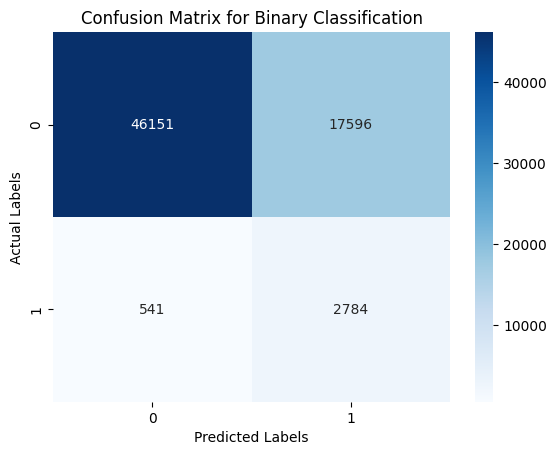

In [13]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Binary Classification')
plt.show()

In [14]:
model.evaluate(test_dataset)

2096/2096 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.7556 - auc: 0.8626 - loss: 0.8504 - precision_1: 0.1378


2024-10-24 16:22:48.710038: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
2024-10-24 16:22:48.710144: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2024-10-24 16:22:48.710156: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 5904336274930270069
2024-10-24 16:22:48.710177: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 14143473200865

[0.883551836013794,
 0.7295891046524048,
 0.8498641848564148,
 0.13660451769828796]